# 1. Import und Hardware Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split, Subset

import matplotlib.pyplot as plt

!pip install tqdm ipywidgets -q
from tqdm.auto import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
DATA_PATH = './Data'

# 2. Hyperparameters

In [4]:
IMG_SIZE = 224
IN_CHANNELS = 3
BATCH_SIZE = 128
NUM_CLASSES = 101

EPOCHS = 20
LR = 0.1

# 3. Data Preparation

In [5]:
stats = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats),
    transforms.RandomErasing(p=0.5, scale=(0.02, 0.33), ratio=(0.3, 3.3), value='random')
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [6]:
# Download train data first without transform
dummy_data = datasets.Food101(root=DATA_PATH, split='train', download=True)

# Split the train data into train and validation data
train_size = int(0.8 * len(dummy_data))
val_size = len(dummy_data) - train_size
train_subset_tmp, val_subset_tmp = random_split(dummy_data, [train_size, val_size])

# Extract indices
train_idx = train_subset_tmp.indices
val_idx = val_subset_tmp.indices

# Create train and validation subset
train_dataset = datasets.Food101(root=DATA_PATH, split='train',
                                download=False, transform=train_transform)
val_dataset = datasets.Food101(root=DATA_PATH, split='train',
                               download=False, transform=test_transform)

train_subset = Subset(train_dataset, train_idx)
val_subset = Subset(val_dataset, val_idx)

# Download test data
test_dataset = datasets.Food101(root=DATA_PATH, split='test',
                                download=True, transform=test_transform)

100%|██████████| 5.00G/5.00G [04:09<00:00, 20.0MB/s] 


In [7]:
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=1, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=1, pin_memory=True, persistent_workers=True)

# 4. Setup Pre-trained Model

In [8]:
# Download the pretrained model
model = models.resnet18(models.ResNet18_Weights.IMAGENET1K_V1, False)

# Modify head for 101 Classes
model.fc = nn.Linear(512, NUM_CLASSES)

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:135: UserWarning: Using 'weights' and 'progress' as positional parameter(s) is deprecated since 0.13 and may be removed in the future. Please use keyword parameter(s) instead.
  warnings.warn(


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


# 5. Training Preparation

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05, betas=(0.9, 0.999))

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

scaler = torch.amp.GradScaler(device=device)

In [ ]:
class EarlyStopping(nn.Module):
    def __init__(self, patience=10, delta=0, verbose=False, save_path='best_checkpoint.pth'):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.save_path = save_path
        self.best_loss = None
        self.early_stop = False
        self.counter = 0

    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss > self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print("Saving best checkpoint ... ")
        state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(state_dict, self.save_path)

In [11]:
def train(model, loader, criterion, optimizer, scaler):
    model.train()
    train_loss, train_acc = 0, 0
    loop = tqdm(loader, desc="Training", leave=False)
    
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        
        # Zero out the gradients of last batch
        optimizer.zero_grad(set_to_none=True)
        
        # Get output and loss using Mixed Precision
        with torch.amp.autocast(device_type=device.type):
            out = model(x)
            loss = criterion(out, y)
        
        # Scale up the gradients and backpropagate
        scaler.scale(loss).backward()
        
        # Scale down and clip the gradients
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Check if the Gradients are valid
        scaler.step(optimizer)
        
        # Update the scaler
        scaler.update()
        
        # Sum up loss and acc
        train_loss += loss.detach() * x.size(0)
        train_acc += (out.argmax(1) == y).sum()
        
    return train_loss.item() / len(loader.dataset), train_acc.item() / len(loader.dataset)
        

In [12]:
def validate(model, loader, criterion):
    model.eval()
    val_loss = 0
    loop = tqdm(loader, desc="Validation", leave=False)
    
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        
        with torch.no_grad():
            out = model(x)
            loss = criterion(out, y)
            
        val_loss += loss.detach() * x.size(0)
        
    return val_loss.item() / len(loader.dataset)

In [13]:
def test(model, loader):
    model.eval()
    test_acc = 0
    loop = tqdm(loader, desc="Testing", leave=False)
    
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        
        with torch.no_grad():
            out = model(x)
            
        test_acc += (out.argmax(1) == y).sum()
        
    return test_acc.item() / len(loader.dataset)

# 6. Train

In [14]:
train_losses, val_losses = [], []
train_accuracies, test_accuracies = [], []
early_stopping = EarlyStopping(patience=3)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scaler)
    val_loss = validate(model, val_loader, criterion)
    test_acc = test(model, test_loader)
    
    scheduler.step()
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: train_loss: {train_loss:.4f}, val_loss: {val_loss:.4f}, " +
          f"train_acc: {train_acc:.4f}, test_acc: {test_acc:.4f}")
    
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early Stopping")
        break


Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Testing:   0%|          | 0/198 [00:00<?, ?it/s]

Epoch 1/10: train_loss: 2.5825, val_loss: 1.7961, train_acc: 0.3899, test_acc: 0.5910


Training:   0%|          | 0/474 [00:00<?, ?it/s]

...

Epoch 9/10: train_loss: 0.8961, val_loss: 1.0385, train_acc: 0.7625, test_acc: 0.7855


Training:   0%|          | 0/474 [00:00<?, ?it/s]

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Testing:   0%|          | 0/198 [00:00<?, ?it/s]

Epoch 10/10: train_loss: 0.8525, val_loss: 1.0180, train_acc: 0.7750, test_acc: 0.7912


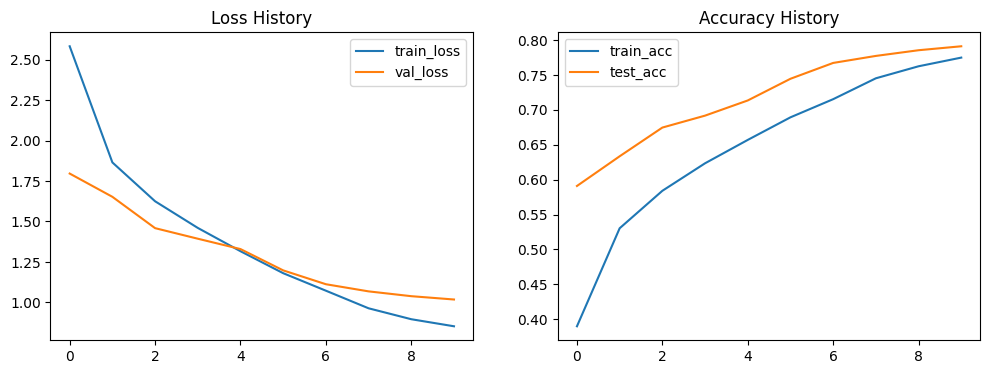

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label= 'train_loss')
plt.plot(val_losses, label = 'val_loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label = 'train_acc')
plt.plot(test_accuracies, label = 'test_acc')
plt.title('Accuracy History')
plt.legend()